# Lab 3 · Part 2 — Running the model as a local service

We now start `serve.py`, a small **web service** built with FastAPI, on **your own computer** (`127.0.0.1` = "this computer", nothing leaves the PC; in Google Colab it runs on the Colab machine).
Then we talk to it the way any other system would: over HTTP, with JSON messages.

```
 this notebook / web browser ── request: an observation (JSON) ──►  serve.py  ──►  lvp_core.py + artifacts/
                             ◄── answer: {"probability": ...} ────
```

**Before starting:** run Part 1 (it creates the `artifacts` folder with the saved model). A ready-trained copy is included, so this part also works on its own.

The model predicts visibility < 1 500 m within 3 hours — a **proxy** for LVP, as stated in the model card.

> **How to use this notebook**
> - Run the cells **one at a time, from top to bottom**: click a cell and press **Shift + Enter**.
> - Every line of code has a comment (the text after `#`) explaining what it does. You do not need to write any code.
> - After each plot there is a short **📖 Reading** that explains what the plot tells us.
> - If something breaks, restart and run everything again: *Kernel → Restart Kernel and Run All Cells* (JupyterLab) or *Runtime → Restart session and run all* (Colab).
> - This notebook is yours to keep: you can re-run it later and change the numbers to experiment.

> ☁️ **Running in Google Colab?** [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/dblue-tech/ai-lab/blob/main/lab3_serving/Lab3_part2_run_the_service.ipynb)  
> Run the next cell **first**: it copies the lab files (data, code, trained models) from GitHub into Colab, so that the rest of the notebook works exactly as on a PC. Wait for *"Colab ready"* (about half a minute).  
> To keep your own copy with your results: *File → Save a copy in Drive*.  
> **On a lab PC** the next cell does nothing: just run it and continue.

In [1]:
# ---- Only for Google Colab: get the lab files. On a lab PC this cell does nothing. ----
import os                                          # os: folders and files
import sys                                         # sys: information about the running Python
import subprocess                                  # subprocess: runs other programs (git, pip)

IN_COLAB = "google.colab" in sys.modules           # True when this notebook runs in Google Colab
if IN_COLAB:                                       # in Colab only:
    if not os.path.exists("/content/ai-lab"):      # if the lab files are not here yet...
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/dblue-tech/ai-lab.git", "/content/ai-lab"], check=True)   # ...copy them from GitHub
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", "fastapi", "uvicorn"], check=True)   # libraries for the service, not pre-installed in Colab
    os.chdir("/content/ai-lab/lab3_serving")       # work inside this notebook's folder, as on a PC
    print("Colab ready — working in", os.getcwd())  # confirm
else:                                              # on a lab PC:
    print("Running on this computer: nothing to do")   # the files are already here

Running on this computer: nothing to do


---
## 0 · Setup

In [2]:
import sys                                        # sys: access to Python's list of code folders
import json                                       # json: reads the model card
import time                                       # time: measures durations
from pathlib import Path                          # Path: file paths that work on every system
import numpy as np                                # numpy: calculations on arrays
import pandas as pd                               # pandas: tables of data
import matplotlib.pyplot as plt                   # matplotlib: plots
import seaborn as sns                             # seaborn: heatmaps
import torch                                      # PyTorch: neural networks

LAB_DIR = Path(".").resolve()                     # this lab's folder (where lvp_core.py and serve.py are)
sys.path.insert(0, str(LAB_DIR))                  # let Python find lvp_core.py
DATA_DIR = LAB_DIR.parent / "data"                # the data folder, next to this lab's folder
ARTIFACTS = LAB_DIR / "artifacts"                 # where the trained model is saved
SEED = 42                                         # fixed seed for random numbers...
torch.manual_seed(SEED)                           # ...in PyTorch...
np.random.seed(SEED)                              # ...and in numpy

import subprocess                                 # subprocess: starts another program (the service) in the background
import requests                                   # requests: sends HTTP requests to the service
import lvp_core                                   # our shared file

PORT = 8000                                       # the "door number" the service listens on
URL = "http://127.0.0.1:" + str(PORT)             # the service address on this computer
IN_COLAB = "google.colab" in sys.modules          # True when running in Google Colab

# ---- Plot style used in the whole notebook (you can skip reading this part) ----
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]  # 8 colours readable by colour-blind people
plt.rcParams["figure.figsize"] = (11, 4)                    # default figure size: 11 x 4 inches
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALETTE)  # use our colours, in this order, for the lines
plt.rcParams["axes.grid"] = True                            # draw a grid behind every plot
plt.rcParams["grid.color"] = "#e6e5e0"                      # make the grid light grey
plt.rcParams["axes.spines.top"] = False                     # hide the top border of the plot
plt.rcParams["axes.spines.right"] = False                   # hide the right border of the plot
plt.rcParams["axes.titleweight"] = "bold"                   # bold titles
plt.rcParams["lines.linewidth"] = 2                         # slightly thicker lines
plt.rcParams["legend.frameon"] = False                      # no box around the legend

---
## 1 · Start the service
The next cell starts the service in the background and waits until it answers.
*(Alternative: in JupyterLab open File → New → Terminal and type `python -m uvicorn serve:app --host 127.0.0.1 --port 8000` — you then see every request live.)*

In [3]:
def service_is_running():                          # returns True if the service answers
    try:                                           # try to contact it...
        answer = requests.get(URL + "/health", timeout=1)   # ...ask the /health address
        return answer.ok                           # True if it answered "OK"
    except requests.ConnectionError:               # if nobody answers...
        return False                               # ...it is not running


server = None                                      # no service started by this notebook yet
if not service_is_running():                       # if the service is not already running...
    command = [sys.executable, "-m", "uvicorn", "serve:app", "--host", "127.0.0.1", "--port", str(PORT)]   # the command
    server = subprocess.Popen(command, cwd=LAB_DIR, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)  # start it
    for attempt in range(60):                      # wait up to 30 seconds (60 x 0.5 s)...
        if service_is_running():                   # ...until it answers
            break                                  # it answers: stop waiting
        if server.poll() is not None:              # if the service stopped by itself...
            print(server.stdout.read())            # ...show its error message (e.g. Part 1 was not run)
            break                                  # and stop waiting
        time.sleep(0.5)                            # wait half a second before trying again

print("Service running:", service_is_running())    # final check

Service running: True


FastAPI automatically documents the service — every input, unit and limit — and lets you try it.
Run the next cell and open the link in a new browser tab (on a lab PC the address is [http://127.0.0.1:8000/docs](http://127.0.0.1:8000/docs)).

In [4]:
if IN_COLAB:                                       # in Colab the service runs on Google's machine, not on your PC...
    from google.colab import output                # ...so Colab gives us a special link to reach it
    output.serve_kernel_port_as_window(PORT, path="/docs", anchor_text="Service documentation")   # show the link
else:                                              # on a lab PC:
    print("Service documentation:", URL + "/docs") # the address on this computer

Service documentation: http://127.0.0.1:8000/docs


---
## 2 · Ask the service

In [5]:
health = requests.get(URL + "/health").json()      # ask /health and decode the JSON answer
print(health)                                      # show it

card = requests.get(URL + "/model").json()         # ask /model: the model card
print("Model:", card["name"], card["version"])     # name and version
print("Alert threshold:", round(card["threshold"], 2))     # threshold
print("Test PR-AUC:", round(card["metrics"]["test_pr_auc"], 3))   # quality on 2025
print("Note:", card["target_note"])                # what the target really means

{'status': 'ok', 'model_version': '1.0.0'}
Model: Low-visibility nowcast LIMC (LVP proxy) 1.0.0
Alert threshold: 0.23
Test PR-AUC: 0.523
Note: Proxy for Low-Visibility Procedures: derived from METAR visibility only. Real LVP depend on RVR, cloud ceiling and local procedures; no LVP declaration data was used.


In [6]:
winter_night = {                                   # one observation, as a dictionary:
    "time": "2025-01-06T03:50:00",                 #   6 January 2025, 03:50 UTC
    "temperature_c": 1.0,                          #   1 °C
    "dewpoint_c": 0.5,                             #   dew point 0.5 °C (almost saturated)
    "wind_dir_deg": None,                          #   calm wind (no direction)
    "wind_speed_kt": 1,                            #   1 knot
    "visibility_m": 2500,                          #   2 500 m
    "qnh_hpa": 1028,                               #   high pressure
}                                                  # (end of the observation)
answer = requests.post(URL + "/predict", json=winter_night)   # send it to /predict
print("HTTP status:", answer.status_code)          # 200 = OK
print(answer.json())                               # the answer of the service

summer_afternoon = {"time": "2025-07-15T14:50:00", "temperature_c": 31, "dewpoint_c": 17, "wind_dir_deg": 200,
                    "wind_speed_kt": 8, "visibility_m": 9999, "qnh_hpa": 1014}   # a hot, dry summer afternoon
print(requests.post(URL + "/predict", json=summer_afternoon).json())             # send it and show the answer

HTTP status: 200
{'probability': 0.75777, 'alert': True, 'threshold': 0.23, 'model_version': '1.0.0'}
{'probability': 0.0001, 'alert': False, 'threshold': 0.23, 'model_version': '1.0.0'}


### 2.1 What if…? Probing the model
With a service it is easy to ask many "what if" questions. We keep the winter night and change visibility and temperature − dew point.

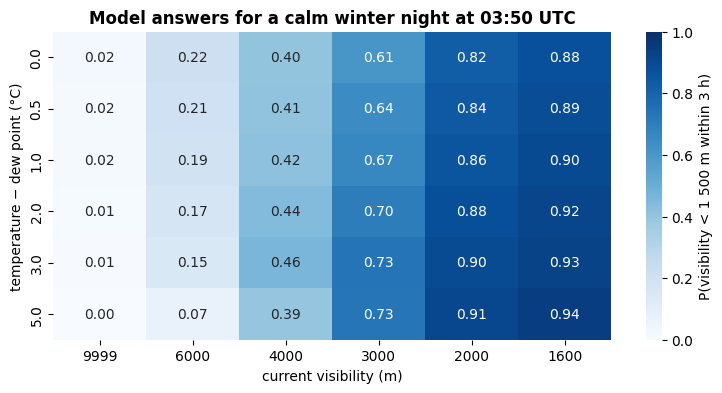

In [7]:
visibilities = [9999, 6000, 4000, 3000, 2000, 1600]        # visibilities to try (m)
spreads = [0, 0.5, 1, 2, 3, 5]                             # temperature − dew point values to try (°C)

observations = []                                          # the list of observations to send
for spread in spreads:                                     # for each spread...
    for visibility in visibilities:                        # ...and each visibility:
        obs = dict(winter_night)                           # copy the winter-night observation
        obs["visibility_m"] = visibility                   # change the visibility
        obs["dewpoint_c"] = winter_night["temperature_c"] - spread   # change the dew point to get this spread
        observations.append(obs)                           # add it to the list

answers = requests.post(URL + "/predict_batch", json=observations).json()   # send all of them in one request
probabilities = []                                         # collect the probabilities
for a in answers:                                          # for each answer...
    probabilities.append(a["probability"])                 # ...take its probability
grid = np.array(probabilities).reshape(len(spreads), len(visibilities))     # arrange them in a grid (rows = spreads)
grid = pd.DataFrame(grid, index=spreads, columns=visibilities)              # label rows and columns

plt.figure(figsize=(9, 4))                                 # new figure
sns.heatmap(grid, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
            cbar_kws={"label": "P(visibility < 1 500 m within 3 h)"})   # coloured grid with the values written in it
plt.grid(False)                                            # no grid lines over the heatmap
plt.xlabel("current visibility (m)")                       # horizontal axis label
plt.ylabel("temperature − dew point (°C)")                 # vertical axis label
plt.title("Model answers for a calm winter night at 03:50 UTC")   # title
plt.show()                                                 # display

📖 **Reading:** the risk rises strongly as visibility falls — sensible. But look along the rows: at low visibility, *drier* air (larger spread) slightly
**increases** the risk, which is physically implausible. The model has learned correlations, not physics, and relies almost entirely on current visibility.
**No score in Lab 2 revealed this — probing did.** This is a cheap and powerful check before trusting a model.

---
## 3 · The service protects the model: invalid requests

In [8]:
bad_requests = {}                                          # a dictionary: description -> bad observation
bad = dict(winter_night)                                   # copy the good observation...
bad["temperature_c"] = 95.0                                # ...temperature in °F by mistake
bad_requests["temperature in °F by mistake"] = bad         # store it

bad = dict(winter_night)                                   # copy again...
bad["dewpoint_c"] = 5.0                                    # ...dew point above the temperature
bad_requests["dew point above temperature"] = bad          # store it

bad = dict(winter_night)                                   # copy again...
del bad["visibility_m"]                                    # ...remove the visibility
bad_requests["missing visibility"] = bad                   # store it

bad = dict(winter_night)                                   # copy again...
bad["visibility_m"] = "CAVOK"                              # ...text instead of a number
bad_requests["visibility as text"] = bad                   # store it

for description in bad_requests:                           # for each bad observation...
    answer = requests.post(URL + "/predict", json=bad_requests[description])   # ...send it
    message = answer.json()["detail"][0]["msg"]            # the explanation given by the service
    print(description, "-> HTTP", answer.status_code, ":", message)            # show status and explanation

temperature in °F by mistake -> HTTP 422 : Input should be less than or equal to 50
dew point above temperature -> HTTP 422 : Value error, dew point cannot be higher than temperature
missing visibility -> HTTP 422 : Field required
visibility as text -> HTTP 422 : Input should be a valid number, unable to parse string as a number


📖 **Reading:** HTTP **422** means *"I understood your request, but the data breaks the rules"*. The model never sees these inputs.
Without these checks, a temperature in °F would silently produce a confident — and wrong — probability.

---
## 4 · Does the service give the same answers as the notebook?
We send the whole **2025** year to the service and compare with the probabilities computed directly from the saved model.
Any difference would mean that training and serving prepare the data differently (**training/serving skew**).

In [9]:
weather = lvp_core.load_iem_metar(DATA_DIR / "LIMC.csv")   # the archive in aviation units
year_2025 = weather.loc["2025"]                            # only 2025
needed = ["temperature_c", "dewpoint_c", "wind_speed_kt", "visibility_m", "qnh_hpa"]   # inputs that must be present
year_2025 = year_2025.dropna(subset=needed)                # keep only complete observations
year_2025 = year_2025[year_2025["dewpoint_c"] <= year_2025["temperature_c"] + 0.5]    # respect the dew point rule

records = []                                               # the observations, as dictionaries for the service
for timestamp, row in year_2025.iterrows():                # for each hour of 2025...
    record = {}                                            # ...build one observation:
    record["time"] = timestamp.strftime("%Y-%m-%dT%H:%M:%S")   # time as text
    record["temperature_c"] = float(row["temperature_c"])  # temperature
    record["dewpoint_c"] = float(row["dewpoint_c"])        # dew point
    if pd.isna(row["wind_dir_deg"]):                       # if the wind direction is missing (calm)...
        record["wind_dir_deg"] = None                      # ...send "empty" (JSON null)
    else:                                                  # otherwise...
        record["wind_dir_deg"] = float(row["wind_dir_deg"])   # ...send the direction
    record["wind_speed_kt"] = float(row["wind_speed_kt"])  # wind speed
    record["visibility_m"] = float(row["visibility_m"])    # visibility
    record["qnh_hpa"] = float(row["qnh_hpa"])              # pressure
    records.append(record)                                 # add it to the list

start = time.time()                                        # start the stopwatch
service_probabilities = []                                 # the answers of the service
for first in range(0, len(records), 1000):                 # send the observations 1 000 at a time
    batch = records[first:first + 1000]                    # the next 1 000 observations
    answers = requests.post(URL + "/predict_batch", json=batch).json()   # ask the service
    for a in answers:                                      # for each answer...
        service_probabilities.append(a["probability"])     # ...keep the probability
service_probabilities = np.array(service_probabilities)    # as a numpy array
print(len(service_probabilities), "predictions from the service in", round(time.time() - start, 1), "seconds")   # speed

local_probabilities = lvp_core.LoadedModel(ARTIFACTS).predict_probability(year_2025)   # same predictions, directly
largest = np.abs(service_probabilities - local_probabilities).max()   # the largest difference
print("Largest difference service vs notebook:", largest)  # only rounding (the service rounds to 5 decimals)

8689 predictions from the service in 0.2 seconds
Largest difference service vs notebook: 4.999869361199671e-06


📖 **Reading:** the differences are only rounding: training and serving agree **because both use the same `lvp_core.py`**.

### 4.1 What a unit mistake by a client looks like
Imagine a client system that forgets the unit conversion and sends visibility in **statute miles** (as in the raw archive): values like `0.5` or `6.2`.
These values are *inside* the allowed range 0–9 999, so the service cannot reject them!

Hours with an alert — correct units: 10.7 %
Hours with an alert — visibility in miles: 91.9 %


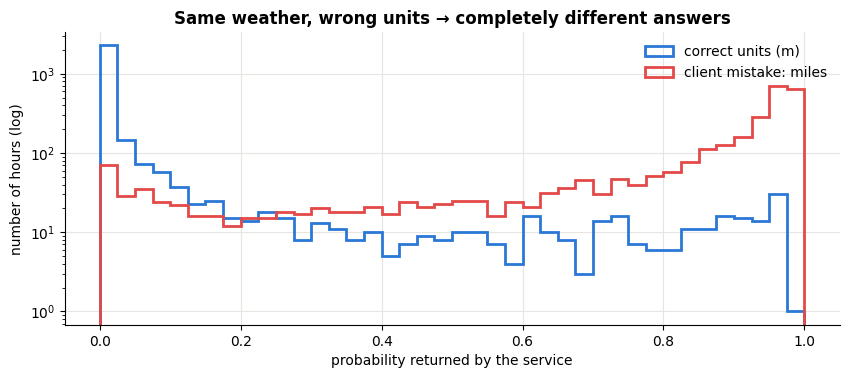

In [10]:
wrong_records = []                                         # the same observations, with the mistake
for record in records[:3000]:                              # take the first 3 000 hours of 2025
    wrong = dict(record)                                   # copy the observation
    wrong["visibility_m"] = round(record["visibility_m"] / 1609.34, 2)   # visibility in miles instead of metres
    wrong_records.append(wrong)                            # add it to the list

answers = requests.post(URL + "/predict_batch", json=wrong_records).json()   # send them
wrong_probabilities = []                                   # collect the probabilities
for a in answers:                                          # for each answer...
    wrong_probabilities.append(a["probability"])           # ...keep the probability
wrong_probabilities = np.array(wrong_probabilities)        # as a numpy array
right_probabilities = service_probabilities[:3000]         # the correct answers for the same hours

right_alert_share = np.mean(right_probabilities >= card["threshold"]) * 100   # % of hours with an alert (correct units)
wrong_alert_share = np.mean(wrong_probabilities >= card["threshold"]) * 100   # % of hours with an alert (wrong units)
print("Hours with an alert — correct units:", round(right_alert_share, 1), "%")      # show both
print("Hours with an alert — visibility in miles:", round(wrong_alert_share, 1), "%")

plt.figure(figsize=(10, 3.8))                              # new figure
plt.hist(right_probabilities, bins=40, range=(0, 1), histtype="step", linewidth=2, color=PALETTE[0], label="correct units (m)")   # correct
plt.hist(wrong_probabilities, bins=40, range=(0, 1), histtype="step", linewidth=2, color=PALETTE[7], label="client mistake: miles")  # wrong
plt.yscale("log")                                          # log scale
plt.xlabel("probability returned by the service")          # horizontal axis label
plt.ylabel("number of hours (log)")                        # vertical axis label
plt.title("Same weather, wrong units → completely different answers")   # title
plt.legend()                                               # legend
plt.show()                                                 # display

📖 **Reading:** with the unit mistake, almost every hour looks like thick fog and the service raises alerts nearly all the time.
**Input checks catch impossible values, not plausible-but-wrong ones.** Real deployments add **monitoring**: they compare the live inputs and outputs with the training data and raise a warning when they drift apart.

---
## 5 · How fast is the service?

In [11]:
durations_ms = []                                          # time of each request, in milliseconds
for record in records[:200]:                               # send 200 single requests
    start = time.perf_counter()                            # start the stopwatch
    requests.post(URL + "/predict", json=record)           # send one request and wait for the answer
    durations_ms.append((time.perf_counter() - start) * 1000)   # store the elapsed time in ms

print("Median time per request:", round(float(np.median(durations_ms)), 1), "ms")          # typical time
print("95 % of requests faster than:", round(float(np.percentile(durations_ms, 95)), 1), "ms")   # slow cases

Median time per request: 8.5 ms
95 % of requests faster than: 12.5 ms


📖 **Reading:** a few milliseconds per request. The neural network itself needs microseconds; most of the time is spent sending messages.
Sending many observations in one request (as in §4) is much faster per prediction.

---
## 6 · The web form
A simple page that calls the same `/predict` address. Run the next cell and open the link (on a lab PC: [http://127.0.0.1:8000/](http://127.0.0.1:8000/)). Try the two example buttons, then invent your own situation.

In [12]:
if IN_COLAB:                                       # in Colab the service runs on Google's machine, not on your PC...
    from google.colab import output                # ...so Colab gives us a special link to reach it
    output.serve_kernel_port_as_window(PORT, path="/", anchor_text="Web form")   # show the link
else:                                              # on a lab PC:
    print("Web form:", URL + "/")                  # the address on this computer

Web form: http://127.0.0.1:8000/


---
## 7 · Stop the service

In [13]:
if server is not None:                                     # if this notebook started the service...
    server.terminate()                                     # ...ask it to stop...
    server.wait(timeout=10)                                # ...and wait until it has stopped
    print("Service stopped")                               # confirm
else:                                                      # otherwise it was started from a terminal...
    print("Stop the service in its terminal with Ctrl+C")  # ...and must be stopped there

Service stopped


---
## 8 · Questions for discussion
1. What would go wrong if we shipped only the weights (`model_state.pt`) without the model card?
2. The service rejected temperatures in °F but not visibility in miles. What checks or monitoring could catch the miles mistake?
3. Our service only answers on `127.0.0.1` (this computer). What changes — technically and in terms of security and responsibility — if other systems must reach it?
4. A new version of the model is trained next year. How would you replace the old one safely?
5. The model card says the target is a **proxy** for LVP. Who reads a model card, and why does that sentence matter?

## ⚠️ Things that often go wrong when serving models
> - **"Address already in use"**: a service from a previous run is still running on port 8000. Restart the kernel, or stop it in its terminal.
> - **The service does not start**: usually Part 1 has not been run, so the `artifacts` folder is missing. The start cell prints the error.
> - **Changes to `serve.py` have no effect**: the running service still uses the old code — stop it and start it again.